# Experiment 8: K-Reciprocal Re-Ranking for Jaguar Re-Identification

**Research Question:** Does k-reciprocal re-ranking a post-processing step
applied to the similarity matrix of a frozen trained model improve
identity-balanced mAP, and what parameter configuration (k₁, k₂, λ) works
best for the jaguar dataset?

**Reference:** Zhong et al., "Re-ranking Person Re-Identification with
k-reciprocal Encoding", CVPR 2017.

## Overview

1. **Data Loading**: Stratified train/validation split
2. **Backbone + Embedding Extraction**: Freeze MegaDescriptor-L-384, extract and cache
3. **Model Training**: Train ArcFace projection head, save best checkpoint
4. **Reload Best Checkpoint**: Verify weights before evaluation
5. **Baseline mAP**: Single-pass cosine similarity, no re-ranking
6. **K-Reciprocal Re-Ranking**: Implement Zhong et al. algorithm
7. **Parameter Ablation**: Sweep k₁ ∈ {10,15,20,25,30}, k₂ ∈ {3,6,9}, λ ∈ {0.1,0.3,0.5}
8. **Results and Analysis**: Best config, per-identity gains, compute cost
9. **Submission**: Best configuration applied to test set

## What is K-Reciprocal Re-Ranking?

Standard retrieval ranks gallery items by cosine similarity to the query.
K-reciprocal re-ranking refines this by asking: *if item g is in the top-k
neighbours of query q, is q also in the top-k neighbours of g?*
Mutual (reciprocal) neighbours are more likely to be true matches.

The algorithm replaces the original distance matrix with a **Jaccard distance**
computed from reciprocal neighbourhood overlap, then blends both:

```
final_distance = (1 − λ) × jaccard_distance + λ × original_distance
```

**Three parameters to tune:**
- **k₁**: size of the k-reciprocal neighbourhood (most impactful; typical 10–30)
- **k₂**: neighbours for local query expansion (stabiliser; typical 3–10)
- **λ**: blend weight between Jaccard and original distance (typical 0.2–0.5)

## Why No Retraining Is Needed After the First Run
Re-ranking operates entirely on the pre-computed embedding matrix.
Once the model is trained and embeddings are extracted, the full parameter
sweep is **pure numpy** — no GPU required.


## 1. Setup and Configuration

In [1]:
import os
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from itertools import product
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import wandb
from kaggle_secrets import UserSecretsClient

# Secrets
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

# Reproducibility
RANDOM_SEED = 42

def set_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {device}")
print(f"PyTorch: {torch.__version__}  |  timm: {timm.__version__}")


Device:  cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


In [2]:
RANDOM_SEED = 42

# Re-ranking parameter search space
# k₁: size of k-reciprocal neighbourhood (most impactful)
K1_VALUES  = [10, 15, 20, 25, 30]
# k₂: local query expansion size (stabiliser)
K2_VALUES  = [3, 6, 9]
# λ: blend weight (0 = pure Jaccard, 1 = pure original distance)
LAMBDA_VALUES = [0.1, 0.3, 0.5]

config = {
    # Paths
    "data_dir":       Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "cache_dir":      Path("/kaggle/working/embeddings"),

    # Backbone (frozen)
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size":            384,

    # Projection head (same as prior experiments)
    "embedding_dim":  256,
    "hidden_dim":     512,
    "dropout":        0.3,

    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale":  64.0,

    # Training
    "batch_size":     32,
    "learning_rate":  1e-4,
    "weight_decay":   1e-4,
    "num_epochs":     50,
    "patience":       10,
    "val_split":      0.2,
    "seed":           RANDOM_SEED,

    # Re-ranking defaults (Zhong et al. recommendations)
    "k1_default": 20,
    "k2_default": 6,
    "lambda_default": 0.3,
}

CHECKPOINT_PATH = config["checkpoint_dir"] / "rerank_arcface_best.pth"
config["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
config["cache_dir"].mkdir(parents=True, exist_ok=True)

total_configs = len(K1_VALUES) * len(K2_VALUES) * len(LAMBDA_VALUES)
print("K-Reciprocal Re-Ranking Configuration:")
print(f"  Backbone:       {config['megadescriptor_model']}")
print(f"  Checkpoint:     {CHECKPOINT_PATH}")
print(f"  k₁ values:      {K1_VALUES}")
print(f"  k₂ values:      {K2_VALUES}")
print(f"  λ  values:      {LAMBDA_VALUES}")
print(f"  Total configs:  {total_configs}  (pure numpy, no GPU)")
print(f"  Zhong defaults: k₁={config['k1_default']}, "
      f"k₂={config['k2_default']}, λ={config['lambda_default']}")


Q8 K-Reciprocal Re-Ranking Configuration:
  Backbone:       hf-hub:BVRA/MegaDescriptor-L-384
  Checkpoint:     /kaggle/working/checkpoints/rerank_arcface_best.pth
  k₁ values:      [10, 15, 20, 25, 30]
  k₂ values:      [3, 6, 9]
  λ  values:      [0.1, 0.3, 0.5]
  Total configs:  45  (pure numpy, no GPU)
  Zhong defaults: k₁=20, k₂=6, λ=0.3


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        "experiment":      "k-reciprocal-reranking",
        "backbone":        config["megadescriptor_model"],
        "embedding_dim":   config["embedding_dim"],
        "hidden_dim":      config["hidden_dim"],
        "dropout":         config["dropout"],
        "arcface_margin":  config["arcface_margin"],
        "arcface_scale":   config["arcface_scale"],
        "batch_size":      config["batch_size"],
        "learning_rate":   config["learning_rate"],
        "weight_decay":    config["weight_decay"],
        "num_epochs":      config["num_epochs"],
        "patience":        config["patience"],
        "val_split":       config["val_split"],
        "seed":            config["seed"],
        "k1_values":       K1_VALUES,
        "k2_values":       K2_VALUES,
        "lambda_values":   LAMBDA_VALUES,
        "total_configs":   total_configs,
    },
    name="k-reciprocal-rerank",
)
print("W&B run initialised: k-reciprocal-rerank")
print("  Training metrics  → training/")
print("  Per-config mAP    → rerank/{k1}_{k2}_{lam}/val_map")
print("  Final results     → results/")


W&B run initialised: k-reciprocal-rerank-q8
  Training metrics  → training/
  Per-config mAP    → rerank/{k1}_{k2}_{lam}/val_map
  Final results     → results/


## 2. Load and Prepare Data

In [5]:
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images:      {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(train_df.head())

identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min:  {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max:  {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean: {identity_counts.mean():.1f}")


Training dataset:
  Total images:      1895
  Unique identities: 31
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min:  13 (Ipepo)
  Max:  183 (Marcela)
  Mean: 61.1


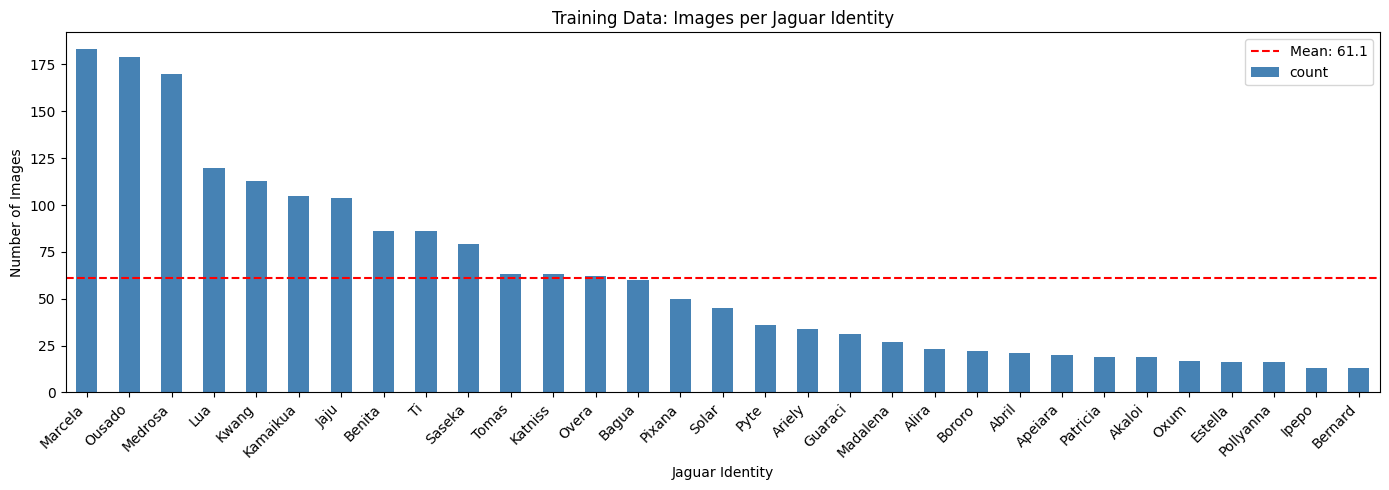

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=identity_counts.mean(), color='red', linestyle='--',
           label=f'Mean: {identity_counts.mean():.1f}')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Jaguar Identity')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
wandb.log({"identity_distribution": wandb.Image(fig)})
plt.show()


In [7]:
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size    = config["val_split"],
    random_state = config["seed"],
    stratify     = train_df['ground_truth'],
)

train_identities = set(train_data['ground_truth'].unique())
val_identities   = set(val_data['ground_truth'].unique())
assert train_identities == val_identities, "Some identities missing from val!"

train_labels_enc = train_data['label_encoded'].values
val_labels_enc   = label_encoder.transform(val_data['ground_truth'].values)
val_labels_str   = val_data['ground_truth'].values

train_paths = [config["data_dir"] / "train/train" / fn
               for fn in train_data["filename"].astype(str)]
val_paths   = [config["data_dir"] / "train/train" / fn
               for fn in val_data["filename"].astype(str)]

print(f"Train: {len(train_data)}  |  Val: {len(val_data)}  |  Classes: {num_classes}")
print("All identities present in both sets ✓")

wandb.log({
    "num_identities": num_classes,
    "train_samples":  len(train_data),
    "val_samples":    len(val_data),
})


Train: 1516  |  Val: 379  |  Classes: 31
All identities present in both sets ✓


## 3. Load MegaDescriptor and Extract Embeddings

In [8]:
print("Loading MegaDescriptor-L-384...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained  = True,
    num_classes = 0,
    img_size    = config["input_size"],
)
megadescriptor.eval()
for p in megadescriptor.parameters():
    p.requires_grad = False
megadescriptor.to(device)

with torch.no_grad():
    dummy = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    megadescriptor_dim = megadescriptor(dummy).shape[1]

print(f"  Embedding dim: {megadescriptor_dim}")
print(f"  Parameters:    {sum(p.numel() for p in megadescriptor.parameters()):,}")
print(f"  Frozen:        True")

preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


Loading MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

  Embedding dim: 1536
  Parameters:    195,198,516
  Frozen:        True


In [9]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32,
                        desc="Extracting embeddings"):
    model.eval()
    all_embs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        paths   = image_paths[i:i + batch_size]
        tensors = []
        for p in paths:
            try:
                tensors.append(preprocess(Image.open(p).convert("RGB")))
            except Exception as e:
                print(f"  [WARN] {p}: {e}")
                tensors.append(torch.zeros(3, config["input_size"],
                                           config["input_size"]))
        all_embs.append(
            model(torch.stack(tensors).to(device)).cpu().numpy())
    return np.vstack(all_embs)


tr_cache = config["cache_dir"] / "megadesc_train_embeddings.npz"
if tr_cache.exists():
    train_embeddings = np.load(tr_cache)["embeddings"]
    print(f"Loaded cached train embeddings: {train_embeddings.shape}")
else:
    print(f"Extracting train embeddings for {len(train_paths)} images...")
    train_embeddings = extract_embeddings(
        megadescriptor, train_paths, config["batch_size"], "Train")
    np.savez_compressed(tr_cache, embeddings=train_embeddings)
    print(f"Saved: {train_embeddings.shape}")

va_cache = config["cache_dir"] / "megadesc_val_embeddings.npz"
if va_cache.exists():
    val_embeddings = np.load(va_cache)["embeddings"]
    print(f"Loaded cached val embeddings:   {val_embeddings.shape}")
else:
    print(f"Extracting val embeddings for {len(val_paths)} images...")
    val_embeddings = extract_embeddings(
        megadescriptor, val_paths, config["batch_size"], "Val")
    np.savez_compressed(va_cache, embeddings=val_embeddings)
    print(f"Saved: {val_embeddings.shape}")


Extracting train embeddings for 1516 images...


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Saved: (1516, 1536)
Extracting val embeddings for 379 images...


Val:   0%|          | 0/12 [00:00<?, ?it/s]

Saved: (379, 1536)


## 4. Model Architecture

In [10]:
class EmbeddingProjection(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x): return self.net(x)


class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.scale  = scale
        self.cos_m  = math.cos(margin); self.sin_m = math.sin(margin)
        self.th     = math.cos(math.pi - margin)
        self.mm     = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.weight, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1.0, 1.0)
        sin   = torch.sqrt(1.0 - cos ** 2)
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(
            1, labels.view(-1, 1).long(), 1.0)
        return (oh * phi + (1 - oh) * cos) * self.scale


class ArcFaceModel(nn.Module):
    def __init__(self, input_dim, num_classes, embedding_dim=256,
                 hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.projection = EmbeddingProjection(input_dim, hidden_dim,
                                               embedding_dim, dropout)
        self.arcface    = ArcFaceHead(embedding_dim, num_classes,
                                      margin=margin, scale=scale)

    def forward(self, x, labels):
        emb    = self.projection(x)
        logits = self.arcface(emb, labels)
        return logits, emb

    def get_embeddings(self, x):
        return F.normalize(self.projection(x), p=2, dim=1)


_m = ArcFaceModel(input_dim=megadescriptor_dim, num_classes=num_classes).to(device)
_x = torch.randn(4, megadescriptor_dim).to(device)
_l = torch.zeros(4, dtype=torch.long).to(device)
_logits, _emb = _m(_x, _l)
print(f"ArcFaceModel sanity check: logits={_logits.shape}, emb={_emb.shape}")
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _l, _logits, _emb


ArcFaceModel sanity check: logits=torch.Size([4, 31]), emb=torch.Size([4, 256])
  Params: 927,744


## 5. Training Utilities

In [12]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):          return len(self.labels)
    def __getitem__(self, idx): return self.embeddings[idx], self.labels[idx]


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for emb, labels in pbar:
        emb, labels = emb.to(device), labels.to(device)
        logits, _   = model(emb, labels)
        loss        = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{100.*correct/total:.1f}%")
    return total_loss / len(loader), 100. * correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='Val', leave=False)
        for emb, labels in pbar:
            emb, labels = emb.to(device), labels.to(device)
            logits, _   = model(emb, labels)
            loss        = criterion(logits, labels)
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), 100. * correct / total


def compute_validation_map(model, embeddings, labels_str):
    model.eval()
    with torch.no_grad():
        emb = model.get_embeddings(
            torch.FloatTensor(embeddings).to(device)).cpu().numpy()
    return _map_from_embeddings(emb, labels_str)


def _map_from_embeddings(emb, labels):
    """Identity-balanced mAP from an (N, D) embedding matrix."""    
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sim = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order    = np.argsort(-sim[q]); sm = is_match[order]
        cum      = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


def _map_from_dist_matrix(dist_matrix, labels):
    """Identity-balanced mAP from a pre-computed distance matrix (lower = closer)."""    
    id_aps = defaultdict(list)
    n = len(labels)
    for q in range(n):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        # Sort by ascending distance (ignore self via large self-distance)
        dists = dist_matrix[q].copy(); dists[q] = 1e9
        order = np.argsort(dists); sm = is_match[order]
        cum   = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


print("Training and evaluation utilities defined.")


Training and evaluation utilities defined.


## 6. Train Model and Save Best Checkpoint

Checkpoint not found — training now...


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch   1/50 | TrLoss:36.5123 VaLoss:31.5810 VamAP:0.3339 LR:1.00e-04
    ✓ Saved checkpoint (epoch 1, mAP=0.3339) → /kaggle/working/checkpoints/rerank_arcface_best.pth


Train:   0%|          | 0/48 [00:00<?, ?it/s]

...

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  49/50 | TrLoss:0.8027 VaLoss:4.7294 VamAP:0.7737 LR:1.00e-04
    ✓ Saved checkpoint (epoch 49, mAP=0.7737) → /kaggle/working/checkpoints/rerank_arcface_best.pth


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  50/50 | TrLoss:0.7703 VaLoss:4.6852 VamAP:0.7748 LR:1.00e-04
    ✓ Saved checkpoint (epoch 50, mAP=0.7748) → /kaggle/working/checkpoints/rerank_arcface_best.pth


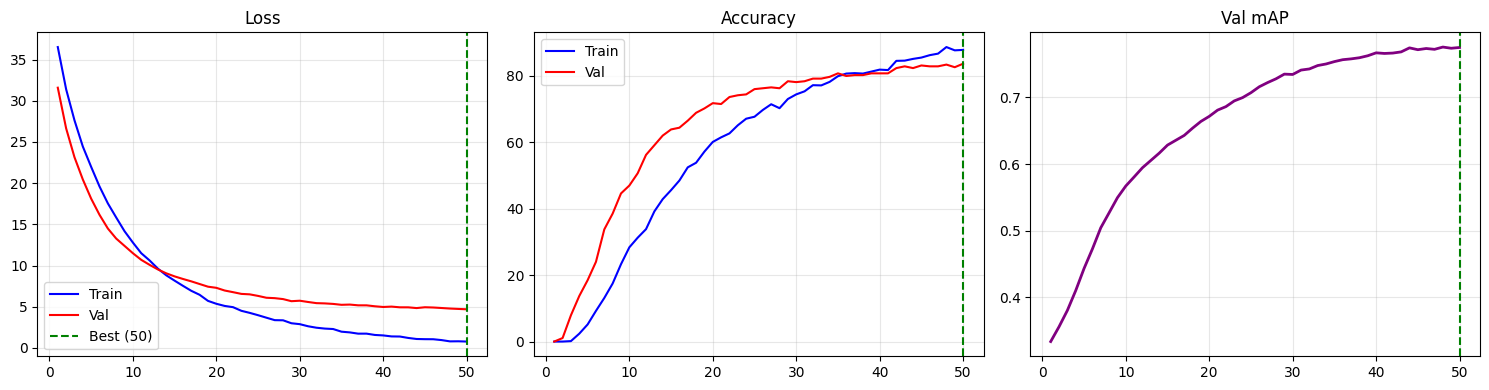


Training complete. Best mAP=0.7748 @ epoch 50


In [13]:
# Guard: retrain only if checkpoint missing
if not CHECKPOINT_PATH.exists():
    print(f"Checkpoint not found — training now...")

    train_dataset = EmbeddingDataset(train_embeddings, train_labels_enc)
    val_dataset   = EmbeddingDataset(val_embeddings, val_labels_enc)
    train_loader  = DataLoader(train_dataset, batch_size=config["batch_size"],
                                shuffle=True,  num_workers=0)
    val_loader    = DataLoader(val_dataset,   batch_size=config["batch_size"],
                                shuffle=False, num_workers=0)

    set_seed(config["seed"])
    model = ArcFaceModel(
        input_dim     = megadescriptor_dim,
        num_classes   = num_classes,
        embedding_dim = config["embedding_dim"],
        hidden_dim    = config["hidden_dim"],
        margin        = config["arcface_margin"],
        scale         = config["arcface_scale"],
        dropout       = config["dropout"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=config["learning_rate"],
                                   weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    history = {k: [] for k in
               ['train_loss','train_acc','val_loss','val_acc','val_map','lr']}
    best_val_loss    = float('inf')
    best_map         = 0.0
    best_epoch       = 0
    patience_counter = 0

    for epoch in range(config['num_epochs']):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion,
                                       optimizer, device)
        va_loss, va_acc = validate_epoch(model, val_loader, criterion, device)
        va_map          = compute_validation_map(
                              model, val_embeddings, val_labels_str)
        scheduler.step(va_loss)
        lr = optimizer.param_groups[0]['lr']

        for k, v in zip(
            ['train_loss','train_acc','val_loss','val_acc','val_map','lr'],
            [tr_loss, tr_acc, va_loss, va_acc, va_map, lr]):
            history[k].append(v)

        wandb.log({
            "training/epoch":      epoch + 1,
            "training/train_loss": tr_loss,
            "training/train_acc":  tr_acc,
            "training/val_loss":   va_loss,
            "training/val_acc":    va_acc,
            "training/val_map":    va_map,
            "training/lr":         lr,
        })

        print(f"  Epoch {epoch+1:3d}/{config['num_epochs']} | "
              f"TrLoss:{tr_loss:.4f} VaLoss:{va_loss:.4f} "
              f"VamAP:{va_map:.4f} LR:{lr:.2e}")

        if va_loss < best_val_loss:
            best_val_loss    = va_loss
            best_map         = va_map
            best_epoch       = epoch + 1
            patience_counter = 0
            torch.save({
                'epoch':              best_epoch,
                'model_state_dict':   model.state_dict(),
                'val_loss':           float(best_val_loss),
                'val_map':            float(best_map),
                'megadescriptor_dim': megadescriptor_dim,
                'num_classes':        num_classes,
                'config':             {k: str(v) if isinstance(v, Path) else v
                                       for k, v in config.items()},
            }, CHECKPOINT_PATH)
            print(f"    ✓ Saved checkpoint (epoch {best_epoch}, "
                  f"mAP={best_map:.4f}) → {CHECKPOINT_PATH}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    wandb.log({
        "training/best_val_map":  best_map,
        "training/best_epoch":    best_epoch,
        "training/best_val_loss": best_val_loss,
    })

    # Training curves
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ep = range(1, len(history['train_loss']) + 1)
    axes[0].plot(ep, history['train_loss'], 'b-', label='Train')
    axes[0].plot(ep, history['val_loss'],   'r-', label='Val')
    axes[0].axvline(x=best_epoch, color='g', linestyle='--',
                    label=f'Best ({best_epoch})')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, history['train_acc'], 'b-', label='Train')
    axes[1].plot(ep, history['val_acc'],   'r-', label='Val')
    axes[1].axvline(x=best_epoch, color='g', linestyle='--')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[2].plot(ep, history['val_map'], 'purple', linewidth=2)
    axes[2].axvline(x=best_epoch, color='g', linestyle='--')
    axes[2].set_title('Val mAP'); axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    wandb.log({"training/curves": wandb.Image(fig)})
    plt.savefig(config["checkpoint_dir"] / 'training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nTraining complete. Best mAP={best_map:.4f} @ epoch {best_epoch}")

else:
    print(f"Checkpoint found at {CHECKPOINT_PATH} — skipping training.")


## 7. Reload Best Checkpoint

We explicitly reload the saved checkpoint and verify the mAP matches before
running any re-ranking evaluation.


In [14]:
print(f"Reloading best checkpoint: {CHECKPOINT_PATH}")
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

reid_model = ArcFaceModel(
    input_dim     = ckpt['megadescriptor_dim'],
    num_classes   = ckpt['num_classes'],
    embedding_dim = config["embedding_dim"],
    hidden_dim    = config["hidden_dim"],
    margin        = config["arcface_margin"],
    scale         = config["arcface_scale"],
    dropout       = config["dropout"],
).to(device)
reid_model.load_state_dict(ckpt['model_state_dict'])
reid_model.eval()
for p in reid_model.parameters():
    p.requires_grad = False

print(f"  Epoch:    {ckpt['epoch']}")
print(f"  val_map:  {ckpt['val_map']:.4f}")
print(f"  val_loss: {ckpt['val_loss']:.4f}")
print(f"  All parameters frozen ✓")

# Verify
reloaded_map = compute_validation_map(reid_model, val_embeddings, val_labels_str)
print(f"\nVerification mAP: {reloaded_map:.4f}  "
      f"(checkpoint: {ckpt['val_map']:.4f})")
assert abs(reloaded_map - ckpt['val_map']) < 0.001, "Checkpoint mAP mismatch!"
print("Checkpoint verified ✓")


Reloading best checkpoint: /kaggle/working/checkpoints/rerank_arcface_best.pth
  Epoch:    50
  val_map:  0.7748
  val_loss: 4.6852
  All parameters frozen ✓

Verification mAP: 0.7748  (checkpoint: 0.7748)
Checkpoint verified ✓


## 8. Extract Fine-Tuned Val Embeddings and Compute Baseline Distance Matrix

We extract the fine-tuned (projected) val embeddings once and store them.
All re-ranking runs will use this same embedding matrix — no further GPU
computation is needed after this cell.


In [15]:
# Extract fine-tuned val embeddings (post-projection, L2-normalised)
with torch.no_grad():
    val_ft_emb = reid_model.get_embeddings(
        torch.FloatTensor(val_embeddings).to(device)).cpu().numpy()

# L2-normalise
val_ft_emb = val_ft_emb / (
    np.linalg.norm(val_ft_emb, axis=1, keepdims=True) + 1e-12)

print(f"Fine-tuned val embeddings: {val_ft_emb.shape}")

# Baseline distance matrix (cosine distance = 1 − cosine similarity)
# This is the "original distance" used as one component in re-ranking
baseline_sim  = val_ft_emb @ val_ft_emb.T                # (N, N) similarities
baseline_dist = 1.0 - baseline_sim                        # (N, N) distances
np.fill_diagonal(baseline_dist, 0.0)                      # self-distance = 0

# Baseline mAP (no re-ranking)
baseline_map = _map_from_dist_matrix(baseline_dist, val_labels_str)
print(f"Baseline mAP (no re-ranking): {baseline_map:.4f}")

wandb.log({
    "results/baseline_map":    baseline_map,
    "results/checkpoint_map":  float(ckpt['val_map']),
})
assert abs(baseline_map - reloaded_map) < 0.001, "Distance matrix mAP mismatch!"
print("Distance matrix baseline verified ✓")
print(f"  Shape: {baseline_dist.shape}  |  Ready for re-ranking sweep.")


Fine-tuned val embeddings: (379, 256)
Baseline mAP (no re-ranking): 0.7748
Distance matrix baseline verified ✓
  Shape: (379, 379)  |  Ready for re-ranking sweep.


## 9. K-Reciprocal Re-Ranking Implementation

Implementation of Zhong et al. CVPR 2017.

**Algorithm:**

1. For each probe i, find its **k₁-reciprocal neighbours** R(i, k₁):
   - Start with the top-k₁ neighbours N(i, k₁)
   - Keep only those j where i is also in N(j, k₁) → reciprocal set R(i, k₁)
   - Expand: for each j ∈ R(i, k₁), if |R(i,k₁) ∩ R(j,k₁)| ≥ ½|R(j,k₁)|, add R(j,k₁)

2. Encode R(i, k₁) as a **sparse vector** V(i) where V(i)[j] is a Gaussian
   kernel weight based on the original distance d(i, j).

3. Apply **local query expansion** with k₂:
   - V̄(i) = (1/(k₂+1)) × (V(i) + Σⱼ∈N(i,k₂) V(j))

4. Compute **Jaccard distance** between expanded vectors:
   - J(i,j) = 1 − |V̄(i) ∩ V̄(j)| / |V̄(i) ∪ V̄(j)|

5. **Final distance**:
   - D(i,j) = (1−λ) × J(i,j) + λ × d_original(i,j)


In [16]:
def k_reciprocal_reranking(embeddings: np.ndarray,
                            k1: int, k2: int, lam: float) -> np.ndarray:
    """
    K-Reciprocal Re-Ranking (Zhong et al., CVPR 2017).

    Args:
        embeddings: (N, D) L2-normalised embedding matrix
        k1:  size of k-reciprocal neighbourhood
        k2:  local query expansion neighbours
        lam: blend weight (0 = pure Jaccard, 1 = pure original dist)

    Returns:
        (N, N) final distance matrix (lower = more similar)
    """
    N = embeddings.shape[0]

    # Original distance matrix
    # Cosine distance = 1 - cosine similarity (embeddings already L2-normalised)
    original_dist = 1.0 - (embeddings @ embeddings.T)
    np.fill_diagonal(original_dist, 0.0)
    # Clip to [0, 2] to handle numerical noise
    original_dist = np.clip(original_dist, 0.0, 2.0)

    # Sort indices by ascending distance for each probe
    # sorted_idx[i] = gallery indices sorted by distance to probe i
    sorted_idx = np.argsort(original_dist, axis=1)   # (N, N)

    # Build k-reciprocal neighbourhood sets
    def get_k_reciprocal(idx, k):
        """Return the k-reciprocal set R(idx, k) as a sorted numpy array."""        # Forward k-nearest (excluding self)
        forward = set(sorted_idx[idx, 1:k+1].tolist())
        # Keep only mutual neighbours
        reciprocal = set()
        for nb in forward:
            backward = set(sorted_idx[nb, 1:k+1].tolist())
            if idx in backward:
                reciprocal.add(nb)
        return np.array(sorted(reciprocal), dtype=np.int32)

    # Sparse Gaussian-weighted feature vectors
    # V[i] is a dense vector of length N; V[i][j] > 0 only if j ∈ R*(i, k1)
    V = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        R_i = get_k_reciprocal(i, k1)

        # Expand: merge R(j, k1/2) if sufficiently overlapping
        R_i_expanded = list(R_i)
        for j in R_i:
            R_j = get_k_reciprocal(j, int(np.ceil(k1 / 2)))
            overlap = len(np.intersect1d(R_i, R_j))
            if overlap >= 0.5 * len(R_j):
                R_i_expanded.extend(R_j.tolist())
        R_i_expanded = np.unique(R_i_expanded).astype(np.int32)

        # Gaussian kernel weights based on original distance
        w = np.exp(-original_dist[i, R_i_expanded])
        w = w / (w.sum() + 1e-12)
        V[i, R_i_expanded] = w.astype(np.float32)

    # Local query expansion with k2
    # V_qe[i] = average of V[i] and its k2 nearest neighbours' V vectors
    if k2 > 0:
        V_qe = np.zeros_like(V)
        for i in range(N):
            k2_neighbours = sorted_idx[i, :k2+1]   # includes self at index 0
            V_qe[i] = V[k2_neighbours].mean(axis=0)
        V = V_qe

    # Jaccard distance
    # J(i,j) = 1 - |V(i) ∩ V(j)| / |V(i) ∪ V(j)|
    # For non-negative V: |V∩V| = sum(min), |V∪V| = sum(max)
    # Vectorised: min_sum = (V + V^T - |V - V^T|) / 2  (too large for full matrix)
    # Use: J = 1 - (V @ V^T) / (||V||₁ + ||V'||₁ - V @ V^T)
    # (approximation valid when V is non-negative)
    VV       = V @ V.T                                   # (N, N) dot products
    norm1    = V.sum(axis=1, keepdims=True)               # (N, 1) L1 norms
    union    = norm1 + norm1.T - VV
    jaccard  = 1.0 - VV / (union + 1e-12)
    jaccard  = np.clip(jaccard, 0.0, 1.0)
    np.fill_diagonal(jaccard, 0.0)

    # Blend Jaccard + original
    final_dist = (1.0 - lam) * jaccard + lam * original_dist
    np.fill_diagonal(final_dist, 0.0)

    return final_dist.astype(np.float32)


# Quick sanity check with Zhong defaults
print("Sanity check: Zhong et al. defaults "
      f"(k1={config['k1_default']}, k2={config['k2_default']}, "
      f"λ={config['lambda_default']})...")
t0   = time.perf_counter()
_d   = k_reciprocal_reranking(
    val_ft_emb,
    k1=config['k1_default'], k2=config['k2_default'],
    lam=config['lambda_default'])
_map = _map_from_dist_matrix(_d, val_labels_str)
_t   = time.perf_counter() - t0
print(f"  Defaults mAP:     {_map:.4f}  (baseline: {baseline_map:.4f})")
print(f"  Gain:             {_map - baseline_map:+.4f}")
print(f"  Time:             {_t:.2f}s")
del _d


Sanity check: Zhong et al. defaults (k1=20, k2=6, λ=0.3)...
  Defaults mAP:     0.7768  (baseline: 0.7748)
  Gain:             +0.0020
  Time:             0.38s


## 10. Full Parameter Sweep

We evaluate all combinations of k₁ × k₂ × λ on the validation set.
All computation is pure numpy — no GPU.


In [17]:
sweep_results = []   # list of dicts
total  = len(K1_VALUES) * len(K2_VALUES) * len(LAMBDA_VALUES)
done   = 0

print(f"Running {total} configurations...")
print(f"  Baseline mAP (no re-ranking): {baseline_map:.4f}")
print()

for k1, k2, lam in product(K1_VALUES, K2_VALUES, LAMBDA_VALUES):
    label = f"k1{k1}_k2{k2}_lam{str(lam).replace('.','')}"

    t0       = time.perf_counter()
    dist_mat = k_reciprocal_reranking(val_ft_emb, k1=k1, k2=k2, lam=lam)
    val_map  = _map_from_dist_matrix(dist_mat, val_labels_str)
    elapsed  = time.perf_counter() - t0

    gain = val_map - baseline_map
    sweep_results.append({
        "label":   label,
        "k1":      k1,
        "k2":      k2,
        "lambda":  lam,
        "val_map": val_map,
        "gain":    gain,
        "time_s":  elapsed,
        "dist_mat": dist_mat,   # keep for per-identity analysis
    })

    wandb.log({
        f"rerank/{label}/val_map": val_map,
        f"rerank/{label}/gain":    gain,
        f"rerank/{label}/time_s":  elapsed,
        f"rerank/{label}/k1":      k1,
        f"rerank/{label}/k2":      k2,
        f"rerank/{label}/lambda":  lam,
    })

    done += 1
    print(f"  [{done:2d}/{total}] k1={k1:2d} k2={k2} λ={lam:.1f} | "
          f"mAP={val_map:.4f} ({gain:+.4f}) | {elapsed:.1f}s")

# Sort by mAP descending
sweep_results.sort(key=lambda r: -r["val_map"])
best_result = sweep_results[0]

print(f"\nBest config: k1={best_result['k1']}, k2={best_result['k2']}, "
      f"λ={best_result['lambda']}")
print(f"  Best mAP:  {best_result['val_map']:.4f}")
print(f"  Baseline:  {baseline_map:.4f}")
print(f"  Gain:      {best_result['gain']:+.4f}")

wandb.log({
    "results/best_k1":        best_result['k1'],
    "results/best_k2":        best_result['k2'],
    "results/best_lambda":    best_result['lambda'],
    "results/best_map":       best_result['val_map'],
    "results/best_gain":      best_result['gain'],
    "results/baseline_map":   baseline_map,
})


Running 45 configurations...
  Baseline mAP (no re-ranking): 0.7748

  [ 1/45] k1=10 k2=3 λ=0.1 | mAP=0.7881 (+0.0133) | 0.2s
  [ 2/45] k1=10 k2=3 λ=0.3 | mAP=0.7819 (+0.0070) | 0.2s
  [ 3/45] k1=10 k2=3 λ=0.5 | mAP=0.7794 (+0.0045) | 0.2s
  [ 4/45] k1=10 k2=6 λ=0.1 | mAP=0.7821 (+0.0072) | 0.2s
  [ 5/45] k1=10 k2=6 λ=0.3 | mAP=0.7769 (+0.0020) | 0.2s
  [ 6/45] k1=10 k2=6 λ=0.5 | mAP=0.7766 (+0.0018) | 0.2s
  [ 7/45] k1=10 k2=9 λ=0.1 | mAP=0.7769 (+0.0021) | 0.2s
  [ 8/45] k1=10 k2=9 λ=0.3 | mAP=0.7757 (+0.0009) | 0.2s
  [ 9/45] k1=10 k2=9 λ=0.5 | mAP=0.7760 (+0.0012) | 0.2s
  [10/45] k1=15 k2=3 λ=0.1 | mAP=0.7892 (+0.0144) | 0.3s
  [11/45] k1=15 k2=3 λ=0.3 | mAP=0.7835 (+0.0087) | 0.3s
  [12/45] k1=15 k2=3 λ=0.5 | mAP=0.7790 (+0.0041) | 0.3s
  [13/45] k1=15 k2=6 λ=0.1 | mAP=0.7779 (+0.0031) | 0.3s
  [14/45] k1=15 k2=6 λ=0.3 | mAP=0.7764 (+0.0016) | 0.3s
  [15/45] k1=15 k2=6 λ=0.5 | mAP=0.7759 (+0.0011) | 0.3s
  [16/45] k1=15 k2=9 λ=0.1 | mAP=0.7720 (-0.0028) | 0.3s
  [17/45] k1=15 k2=

## 11. Results Analysis

In [18]:
print("=" * 65)
print(f"{'Config':30s} | {'mAP':>6} | {'Gain':>7} | {'Time':>6}")
print("-" * 65)
for r in sweep_results[:10]:
    marker = "  << BEST" if r == best_result else ""
    print(f"  {r['label']:28s} | {r['val_map']:.4f} | "
          f"{r['gain']:+.4f} | {r['time_s']:>5.1f}s{marker}")
print("  ...")
print(f"  {'Baseline (no re-ranking)':28s} | {baseline_map:.4f} | "
      f"{'N/A':>7} | {'N/A':>6}")
print("=" * 65)

# Log full results table
rows = []
for r in sweep_results:
    rows.append({
        "k1":       r["k1"],
        "k2":       r["k2"],
        "lambda":   r["lambda"],
        "val_map":  round(r["val_map"], 6),
        "gain":     round(r["gain"], 6),
        "time_s":   round(r["time_s"], 2),
    })
wandb.log({"results/sweep_table": wandb.Table(
    dataframe=pd.DataFrame(rows))})


Config                         |    mAP |    Gain |   Time
-----------------------------------------------------------------
  k115_k23_lam01               | 0.7892 | +0.0144 |   0.3s  << BEST
  k120_k23_lam01               | 0.7885 | +0.0137 |   0.4s
  k110_k23_lam01               | 0.7881 | +0.0133 |   0.2s
  k125_k23_lam01               | 0.7851 | +0.0103 |   0.5s
  k115_k23_lam03               | 0.7835 | +0.0087 |   0.3s
  k130_k23_lam01               | 0.7835 | +0.0086 |   0.6s
  k120_k23_lam03               | 0.7832 | +0.0084 |   0.4s
  k110_k26_lam01               | 0.7821 | +0.0072 |   0.2s
  k110_k23_lam03               | 0.7819 | +0.0070 |   0.2s
  k110_k23_lam05               | 0.7794 | +0.0045 |   0.2s
  ...
  Baseline (no re-ranking)     | 0.7748 |     N/A |    N/A


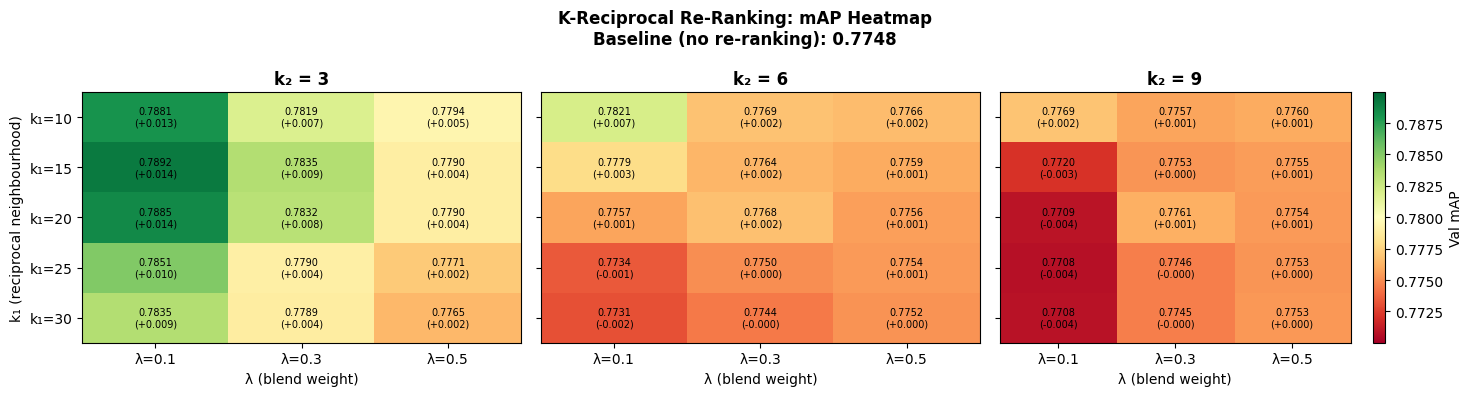

In [19]:
# Heatmap: k1 vs lambda for each k2
fig, axes = plt.subplots(1, len(K2_VALUES), figsize=(5*len(K2_VALUES), 4),
                          sharey=True)
if len(K2_VALUES) == 1:
    axes = [axes]

for ax, k2_val in zip(axes, K2_VALUES):
    grid = np.zeros((len(K1_VALUES), len(LAMBDA_VALUES)))
    for i, k1 in enumerate(K1_VALUES):
        for j, lam in enumerate(LAMBDA_VALUES):
            match = next((r for r in sweep_results
                          if r['k1']==k1 and r['k2']==k2_val
                          and r['lambda']==lam), None)
            if match:
                grid[i, j] = match['val_map']

    vmin = min(r['val_map'] for r in sweep_results)
    vmax = max(r['val_map'] for r in sweep_results)
    im   = ax.imshow(grid, cmap='RdYlGn',
                     vmin=vmin * 0.999, vmax=vmax * 1.001,
                     aspect='auto')
    ax.set_xticks(range(len(LAMBDA_VALUES)))
    ax.set_xticklabels([f"λ={v}" for v in LAMBDA_VALUES])
    ax.set_yticks(range(len(K1_VALUES)))
    ax.set_yticklabels([f"k₁={v}" for v in K1_VALUES])
    ax.set_title(f"k₂ = {k2_val}", fontweight='bold')
    ax.set_xlabel('λ (blend weight)')
    if ax == axes[0]: ax.set_ylabel('k₁ (reciprocal neighbourhood)')

    # Annotate cells
    for i in range(len(K1_VALUES)):
        for j in range(len(LAMBDA_VALUES)):
            gain = grid[i, j] - baseline_map
            ax.text(j, i, f"{grid[i,j]:.4f}\n({gain:+.3f})",
                    ha='center', va='center', fontsize=7,
                    color='black')

plt.colorbar(im, ax=axes[-1], label='Val mAP')
plt.suptitle(f'K-Reciprocal Re-Ranking: mAP Heatmap\n'
             f'Baseline (no re-ranking): {baseline_map:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
wandb.log({"results/heatmap_k1_lambda": wandb.Image(fig)})
plt.savefig(config['checkpoint_dir'] / 'reranking_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()


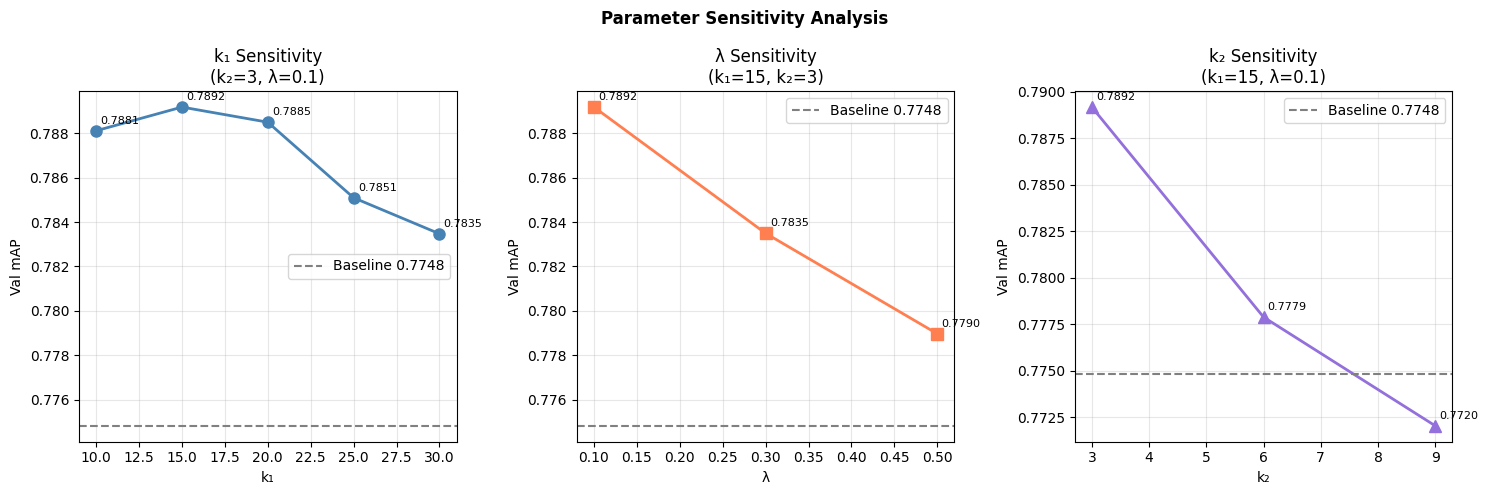

In [20]:
# Sensitivity plots: k1 effect, lambda effect, k2 effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# k1 sensitivity (fix k2 and lambda at best values)
best_k2  = best_result['k2']
best_lam = best_result['lambda']
k1_maps  = []
for k1 in K1_VALUES:
    match = next((r for r in sweep_results
                  if r['k1']==k1 and r['k2']==best_k2
                  and r['lambda']==best_lam), None)
    k1_maps.append(match['val_map'] if match else np.nan)

axes[0].plot(K1_VALUES, k1_maps, 'o-', color='steelblue',
             linewidth=2, markersize=8)
for k1, m in zip(K1_VALUES, k1_maps):
    axes[0].annotate(f"{m:.4f}", (k1, m),
                     textcoords='offset points', xytext=(3, 5), fontsize=8)
axes[0].axhline(y=baseline_map, color='gray', linestyle='--',
                label=f"Baseline {baseline_map:.4f}")
axes[0].set_xlabel('k₁'); axes[0].set_ylabel('Val mAP')
axes[0].set_title(f'k₁ Sensitivity\n(k₂={best_k2}, λ={best_lam})')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# lambda sensitivity (fix k1 and k2 at best values)
best_k1  = best_result['k1']
lam_maps = []
for lam in LAMBDA_VALUES:
    match = next((r for r in sweep_results
                  if r['k1']==best_k1 and r['k2']==best_k2
                  and r['lambda']==lam), None)
    lam_maps.append(match['val_map'] if match else np.nan)

axes[1].plot(LAMBDA_VALUES, lam_maps, 's-', color='coral',
             linewidth=2, markersize=8)
for lam, m in zip(LAMBDA_VALUES, lam_maps):
    axes[1].annotate(f"{m:.4f}", (lam, m),
                     textcoords='offset points', xytext=(3, 5), fontsize=8)
axes[1].axhline(y=baseline_map, color='gray', linestyle='--',
                label=f"Baseline {baseline_map:.4f}")
axes[1].set_xlabel('λ'); axes[1].set_ylabel('Val mAP')
axes[1].set_title(f'λ Sensitivity\n(k₁={best_k1}, k₂={best_k2})')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# k2 sensitivity (fix k1 and lambda at best values)
k2_maps = []
for k2 in K2_VALUES:
    match = next((r for r in sweep_results
                  if r['k1']==best_k1 and r['k2']==k2
                  and r['lambda']==best_lam), None)
    k2_maps.append(match['val_map'] if match else np.nan)

axes[2].plot(K2_VALUES, k2_maps, '^-', color='mediumpurple',
             linewidth=2, markersize=8)
for k2, m in zip(K2_VALUES, k2_maps):
    axes[2].annotate(f"{m:.4f}", (k2, m),
                     textcoords='offset points', xytext=(3, 5), fontsize=8)
axes[2].axhline(y=baseline_map, color='gray', linestyle='--',
                label=f"Baseline {baseline_map:.4f}")
axes[2].set_xlabel('k₂'); axes[2].set_ylabel('Val mAP')
axes[2].set_title(f'k₂ Sensitivity\n(k₁={best_k1}, λ={best_lam})')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Parameter Sensitivity Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
wandb.log({"results/sensitivity_plots": wandb.Image(fig)})
plt.show()


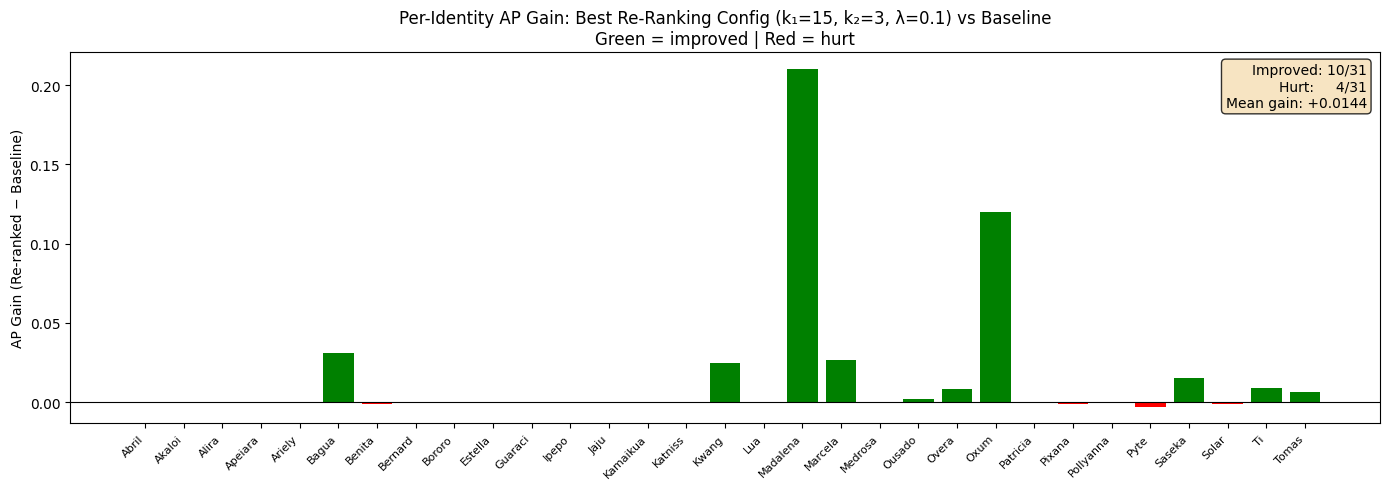

Per-identity summary (best config vs baseline):
  Improved: 10/31
  Hurt:     4/31
  Mean gain: +0.0144


In [22]:
# Per-identity AP: baseline vs best re-ranking config
def per_identity_ap_from_dist(dist_mat, labels):
    """Return {identity: mean_AP} from a distance matrix."""    
    id_aps = defaultdict(list)
    n      = len(labels)
    for q in range(n):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        d        = dist_mat[q].copy(); d[q] = 1e9
        order    = np.argsort(d); sm = is_match[order]
        cum      = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return {k: float(np.mean(v)) for k, v in id_aps.items()}


baseline_per_id = per_identity_ap_from_dist(baseline_dist, val_labels_str)
best_per_id     = per_identity_ap_from_dist(
    best_result['dist_mat'], val_labels_str)

identities = sorted(best_per_id.keys())
gains       = [best_per_id[i] - baseline_per_id.get(i, 0.0) for i in identities]
n_improved  = sum(1 for g in gains if g > 0.001)
n_hurt      = sum(1 for g in gains if g < -0.001)

fig, ax = plt.subplots(figsize=(14, 5))
colors  = ['green' if g > 0.001 else 'red' if g < -0.001 else 'lightgray'
           for g in gains]
ax.bar(range(len(identities)), gains, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(identities)))
ax.set_xticklabels(identities, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('AP Gain (Re-ranked − Baseline)')
ax.set_title(f'Per-Identity AP Gain: Best Re-Ranking Config '
             f'(k₁={best_result["k1"]}, k₂={best_result["k2"]}, '
             f'λ={best_result["lambda"]}) vs Baseline\n'
             f'Green = improved | Red = hurt')
ax.text(0.99, 0.97,
        f'Improved: {n_improved}/{len(identities)}\n'
        f'Hurt:     {n_hurt}/{len(identities)}\n'
        f'Mean gain: {np.mean(gains):+.4f}',
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
wandb.log({"results/per_identity_gain": wandb.Image(fig)})
plt.show()

print(f"Per-identity summary (best config vs baseline):")
print(f"  Improved: {n_improved}/{len(identities)}")
print(f"  Hurt:     {n_hurt}/{len(identities)}")
print(f"  Mean gain: {np.mean(gains):+.4f}")

wandb.log({
    "results/identities_improved": n_improved,
    "results/identities_hurt":     n_hurt,
    "results/mean_per_id_gain":    float(np.mean(gains)),
})


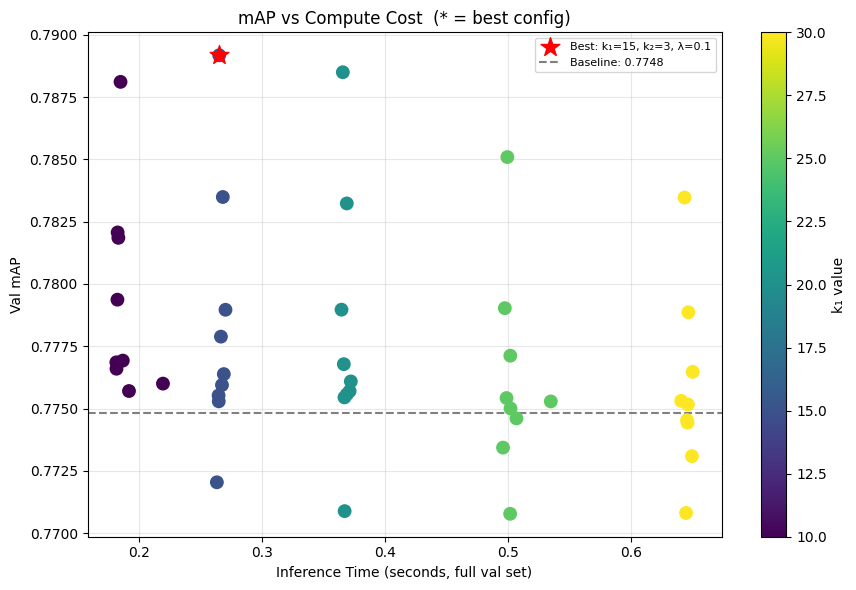

Compute summary:
  Baseline (no re-ranking): ~0s
  Fastest config:  0.18s
  Slowest config:  0.65s
  Best config:     0.27s
  Best mAP gain:   +0.0144


In [23]:
# Compute time analysis
times = [r['time_s'] for r in sweep_results]
maps  = [r['val_map'] for r in sweep_results]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(times, maps, c=[r['k1'] for r in sweep_results],
                cmap='viridis', s=80, zorder=3)
# Mark best
ax.scatter(best_result['time_s'], best_result['val_map'],
           s=200, color='red', marker='*', zorder=4,
           label=f"Best: k₁={best_result['k1']}, k₂={best_result['k2']}, "
                 f"λ={best_result['lambda']}")
ax.axhline(y=baseline_map, color='gray', linestyle='--',
           label=f"Baseline: {baseline_map:.4f}")
plt.colorbar(sc, label='k₁ value')
ax.set_xlabel('Inference Time (seconds, full val set)')
ax.set_ylabel('Val mAP')
ax.set_title('mAP vs Compute Cost  (* = best config)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"results/map_vs_time_scatter": wandb.Image(fig)})
plt.show()

print(f"Compute summary:")
print(f"  Baseline (no re-ranking): ~0s")
print(f"  Fastest config:  {min(times):.2f}s")
print(f"  Slowest config:  {max(times):.2f}s")
print(f"  Best config:     {best_result['time_s']:.2f}s")
print(f"  Best mAP gain:   {best_result['gain']:+.4f}")


## 12. Generate Competition Submission

In [24]:
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")
test_images   = sorted(
    set(test_pairs_df['query_image'].unique()) |
    set(test_pairs_df['gallery_image'].unique()))
test_paths = [config["data_dir"] / "test/test" / fn for fn in test_images]

print(f"Test pairs:     {len(test_pairs_df)}")
print(f"Unique images:  {len(test_images)}")
print(f"Best config:    k₁={best_result['k1']}, "
      f"k₂={best_result['k2']}, λ={best_result['lambda']}")

# Extract test backbone embeddings
te_cache = config["cache_dir"] / "megadesc_test_embeddings.npz"
if te_cache.exists():
    test_backbone_embs = np.load(te_cache)["embeddings"]
    print(f"Loaded cached test backbone embeddings: {test_backbone_embs.shape}")
else:
    print(f"Extracting test backbone embeddings...")
    test_backbone_embs = extract_embeddings(
        megadescriptor, test_paths, config["batch_size"], "Test")
    np.savez_compressed(te_cache, embeddings=test_backbone_embs)

# Project through fine-tuned head
with torch.no_grad():
    test_ft_emb = reid_model.get_embeddings(
        torch.FloatTensor(test_backbone_embs).to(device)).cpu().numpy()
test_ft_emb = test_ft_emb / (
    np.linalg.norm(test_ft_emb, axis=1, keepdims=True) + 1e-12)
print(f"Fine-tuned test embeddings: {test_ft_emb.shape}")


Test pairs:     137270
Unique images:  371
Best config:    k₁=15, k₂=3, λ=0.1
Extracting test backbone embeddings...


Test:   0%|          | 0/12 [00:00<?, ?it/s]

Fine-tuned test embeddings: (371, 256)


In [25]:
# Apply best re-ranking config to test embeddings
print(f"Applying k-reciprocal re-ranking to test set "
      f"(k₁={best_result['k1']}, k₂={best_result['k2']}, "
      f"λ={best_result['lambda']})...")
t0 = time.perf_counter()
test_dist = k_reciprocal_reranking(
    test_ft_emb,
    k1  = best_result['k1'],
    k2  = best_result['k2'],
    lam = best_result['lambda'],
)
print(f"Re-ranking done in {time.perf_counter() - t0:.1f}s")
print(f"Test distance matrix: {test_dist.shape}")

# Convert distance to similarity for submission (similarity = 1 - distance)
# Clip to [0, 1] for safety
test_sim_matrix = np.clip(1.0 - test_dist, 0.0, 1.0)
img_to_idx      = {img: i for i, img in enumerate(test_images)}

similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df),
                   desc="Building submission"):
    qi = img_to_idx[row['query_image']]
    gi = img_to_idx[row['gallery_image']]
    similarities.append(float(test_sim_matrix[qi, gi]))

submission_df = pd.DataFrame({'row_id':     test_pairs_df['row_id'],
                               'similarity': similarities})
submission_path = config['checkpoint_dir'] / 'submission.csv'
submission_df.to_csv(submission_path, index=False)
submission_df.to_csv('/kaggle/working/submission.csv', index=False)
print(f"\nSubmission saved: {submission_path}")
print(f"  Similarity stats: min={min(similarities):.4f}  "
      f"max={max(similarities):.4f}  mean={np.mean(similarities):.4f}")
print(submission_df.head(10))


Applying k-reciprocal re-ranking to test set (k₁=15, k₂=3, λ=0.1)...
Re-ranking done in 0.2s
Test distance matrix: (371, 371)


Building submission:   0%|          | 0/137270 [00:00<?, ?it/s]


Submission saved: /kaggle/working/checkpoints/submission.csv
  Similarity stats: min=0.0000  max=0.1495  mean=0.0074
   row_id  similarity
0       0    0.085834
1       1    0.000000
2       2    0.000000
3       3    0.000000
4       4    0.001535
5       5    0.000000
6       6    0.005404
7       7    0.003137
8       8    0.000000
9       9    0.013989


## 13. Save Artifacts to W&B

In [26]:
# Model checkpoint artifact
model_art = wandb.Artifact("rerank-arcface-model", type="model",
    description="MegaDescriptor + ArcFace — best checkpoint for re-ranking")
model_art.add_file(str(CHECKPOINT_PATH))
wandb.log_artifact(model_art)

# Submission artifact
sub_art = wandb.Artifact("submission", type="submission",
    description=f"K-reciprocal re-ranking | "
                f"k1={best_result['k1']}, k2={best_result['k2']}, "
                f"lam={best_result['lambda']}")
sub_art.add_file(str(submission_path))
wandb.log_artifact(sub_art)

wandb.finish()
print("W&B run completed.")
print(f"Checkpoint:  {CHECKPOINT_PATH}")
print(f"Submission:  {submission_path}")


num_identities,▁
rerank/k110_k23_lam01/gain,▁
rerank/k110_k23_lam01/k1,▁
rerank/k110_k23_lam01/k2,▁
rerank/k110_k23_lam01/lambda,▁
rerank/k110_k23_lam01/time_s,▁
rerank/k110_k23_lam01/val_map,▁
rerank/k110_k23_lam03/gain,▁
rerank/k110_k23_lam03/k1,▁
rerank/k110_k23_lam03/k2,▁
+283,...


W&B run completed.
Checkpoint:  /kaggle/working/checkpoints/rerank_arcface_best.pth
Submission:  /kaggle/working/checkpoints/submission.csv
